In [1]:
import zipfile
import torch
import io
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import torchvision
import torch.nn as nn
from torchvision import transforms, datasets
from sklearn.linear_model import RidgeCV
from sklearn.model_selection import train_test_split
import numpy as np
import os
from scipy.stats import pearsonr
from scipy.signal import butter, sosfiltfilt
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from PIL import Image
from tqdm import tqdm
import torch.nn.functional as F
from torch.utils.data import random_split

In [2]:
def bandpass_filter(
    eeg: np.ndarray,
    lowcut: float = 0.1,
    highcut: float = 20.0,
    fs: float = 250,
    order: int = 5,
) -> np.ndarray:
    if eeg.ndim != 3:
        raise ValueError(f"Expected 3D array (batch, channels, time), got shape {eeg.shape}")

    nyquist = fs / 2.0
    if lowcut <= 0 or highcut >= nyquist:
        raise ValueError(
            f"Cutoff frequencies must satisfy 0 < lowcut < highcut < nyquist ({nyquist} Hz). "
            f"Got lowcut={lowcut}, highcut={highcut}."
        )

    sos = butter(order, [lowcut / nyquist, highcut / nyquist], btype="band", output="sos")

    # Apply filter along time axis for all batch×channels at once
    return sosfiltfilt(sos, eeg, axis=-1)


In [3]:
file_path = "/kaggle/input/datasets/jibrilelhassani/things-meg/things-meg/Preprocessed_data/sub-01/train.pt"

data = torch.load(file_path, map_location="cpu", weights_only=False)

print(type(data))

additional_subs = ["/kaggle/input/datasets/jibrilelhassani/things-meg/things-meg/Preprocessed_data/sub-02/train.pt",\
                   "/kaggle/input/datasets/jibrilelhassani/things-meg/things-meg/Preprocessed_data/sub-03/train.pt",\
                   "/kaggle/input/datasets/jibrilelhassani/things-meg/things-meg/Preprocessed_data/sub-04/train.pt"]
#additional_subs = []

for i in range(len(additional_subs)):
    print("Sub : ", i + 2)
    new_sub = torch.load(additional_subs[i], map_location="cpu", weights_only=False)
    for j in range (len(new_sub['img'])):
        if new_sub['img'][j] == data["img"][j]:
            data["eeg"][j] += new_sub["eeg"][j]
        else :
            print("Miss : ",new_sub['img'][j], data['img'][j])
            raise ValueError

print("Averaging participants...")
eeg = []

for i in range(len(data["eeg"])):

        data["eeg"][i] /= len(additional_subs) +1
        data["eeg"][i] = bandpass_filter(data["eeg"][i])
        if i%1000 ==0:
            print(i)

print("Finished !")
        

<class 'dict'>
Sub :  2
Sub :  3
Sub :  4
Averaging participants...
0
1000
2000
3000
4000
5000
6000
7000
8000
9000
10000
11000
12000
13000
14000
15000
16000
17000
18000
19000
Finished !


In [4]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Running on {device} device")

Running on cuda device


In [5]:
from kaggle_secrets import UserSecretsClient
from huggingface_hub import login

# Authentication : uses kaggle secret to retrieve huggingface token, necessary for access to DINO
user_secrets = UserSecretsClient()
hf_token = user_secrets.get_secret("HF_TOKEN")

# Login
login(token=hf_token)

In [6]:
from transformers import AutoImageProcessor, AutoModel

processor = AutoImageProcessor.from_pretrained("facebook/dinov3-vits16-pretrain-lvd1689m")
model = AutoModel.from_pretrained("facebook/dinov3-vits16-pretrain-lvd1689m")
model.to(device)
model.eval()

preprocessor_config.json:   0%|          | 0.00/585 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/743 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/86.4M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

DINOv3ViTModel(
  (embeddings): DINOv3ViTEmbeddings(
    (patch_embeddings): Conv2d(3, 384, kernel_size=(16, 16), stride=(16, 16))
  )
  (rope_embeddings): DINOv3ViTRopePositionEmbedding()
  (layer): ModuleList(
    (0-11): 12 x DINOv3ViTLayer(
      (norm1): LayerNorm((384,), eps=1e-05, elementwise_affine=True)
      (attention): DINOv3ViTAttention(
        (k_proj): Linear(in_features=384, out_features=384, bias=False)
        (v_proj): Linear(in_features=384, out_features=384, bias=True)
        (q_proj): Linear(in_features=384, out_features=384, bias=True)
        (o_proj): Linear(in_features=384, out_features=384, bias=True)
      )
      (layer_scale1): DINOv3ViTLayerScale()
      (drop_path): Identity()
      (norm2): LayerNorm((384,), eps=1e-05, elementwise_affine=True)
      (mlp): DINOv3ViTMLP(
        (up_proj): Linear(in_features=384, out_features=1536, bias=True)
        (down_proj): Linear(in_features=1536, out_features=384, bias=True)
        (act_fn): GELUActivation()
 

In [7]:
class EEGImageDataset(Dataset):
    def __init__(self, data, base_path):
        self.transform = transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.ToTensor()
        ])

        print("Preloading images into memory...")
        self.samples = []
        counter = 0
        for eeg, img_path in zip(data["eeg"], data["img"]):
            full_path = os.path.join(base_path, img_path)
            img_tensor = self.transform(Image.open(full_path).convert("RGB"))
            with torch.no_grad():
                dino_output = model(img_tensor.to(device).unsqueeze(0))
                feat = dino_output.pooler_output
            
            eeg_tensor = torch.tensor(eeg)[:, :, 25].squeeze()
            self.samples.append((eeg_tensor, img_tensor, feat))
            counter +=1
            if counter%1000 ==0:
                print(counter)

        print(f"Done. {len(self.samples)} samples loaded.")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        return self.samples[idx]

In [9]:

base_path = "/kaggle/input/datasets/jibrilelhassani/things-meg/things-meg/Image_set/"

dataset = EEGImageDataset(data, base_path)
dataloader = DataLoader(dataset, batch_size=32, shuffle=True, num_workers=0)

# Sanity check
eeg_batch, img_batch, dino_output = next(iter(dataloader))
print("EEG batch shape  :", eeg_batch.shape)
print("Image batch shape:", img_batch.shape)
print("Dino feature shape:", dino_output.shape)

Preloading images into memory...
1000
2000
3000
4000
5000
6000
7000
8000
9000
10000
11000
12000
13000
14000
15000
16000
17000
18000
19000
Done. 19848 samples loaded.
EEG batch shape  : torch.Size([32, 271])
Image batch shape: torch.Size([32, 3, 224, 224])
Dino feature shape: torch.Size([32, 1, 384])


In [11]:
torch.save(dataset, '/kaggle/working/image_eeg_dino_dataset.pt')

In [12]:
print("hello")

hello


In [ ]:
### Create Kaggle Dataset

os.makedirs(SAVE_FOLDER, exist_ok=True)
os.makedirs(SAVE_FOLDER + '/folder_name_placeholder/', exist_ok=True)

with open('../input/kaggle-secrets/kaggle.json') as f:
    kaggle_creds = json.load(f)
    
os.environ['KAGGLE_USERNAME'] = kaggle_creds['username']
os.environ['KAGGLE_KEY'] = kaggle_creds['key']

!kaggle datasets init -p '{SAVE_FOLDER}'

with open(f'{SAVE_FOLDER}/dataset-metadata.json') as f:
    dataset_meta = json.load(f)
    
dataset_meta['id'] = f'username_placeholder/{DATASET_NAME}'
dataset_meta['title'] = DATASET_NAME

with open(f'{SAVE_FOLDER}/dataset-metadata.json', "w") as outfile:
    json.dump(dataset_meta, outfile)


!cp '{SAVE_FOLDER}'/dataset-metadata.json '{SAVE_FOLDER}'/meta.json
!ls '{SAVE_FOLDER}'

!kaggle datasets create -u -p '{SAVE_FOLDER}'
Then 

In [8]:
def train_test_split(dataset, test_size=0.2, seed=42):
    n = len(dataset)
    n_test = int(n * test_size)
    n_train = n - n_test
    return random_split(dataset, [n_train, n_test], generator=torch.Generator().manual_seed(seed))

train_dataset, test_dataset = train_test_split(dataset, test_size=0.2)

In [21]:
batch_size = 256
lr = 3e-4
epochs = 200
latent_dim = 512

In [22]:
transform = transforms.Compose([
    transforms.ToTensor(),
])

In [23]:
class Autoencoder(nn.Module):
    def __init__(self):
        super().__init__()

        
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, stride=2, padding=1),   # (16, 112, 112)
            nn.ReLU(),
            nn.Conv2d(16, 32, kernel_size=3, stride=2, padding=1),  # (32, 56, 56)
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),  # (64, 28, 28)
            nn.ReLU(),
            nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1), # (128, 14, 14)
            nn.ReLU(),
            nn.MaxPool2d(kernel_size = 2, stride = 2)
        )

        
        self.flatten = nn.Flatten()
        self.fc_enc = nn.Linear(128 * 7 * 7, latent_dim)

        self.fc_dec = nn.Linear(latent_dim, 128 * 7 * 7)
        self.unflatten = nn.Unflatten(1, (128, 7, 7))

        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(128, 128, 4, stride=2, padding=1), # (128, 14, 14)
            nn.ReLU(),
            nn.ConvTranspose2d(128, 64, 4, stride=2, padding=1),  # (64, 28, 28)
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, 4, stride=2, padding=1),   # (32, 56, 56)
            nn.ReLU(),
            nn.ConvTranspose2d(32, 16, 4, stride=2, padding=1),   # (16, 112, 112)
            nn.ReLU(),
            nn.ConvTranspose2d(16, 3, 4, stride=2, padding=1),    # (3, 224, 224)
            nn.Sigmoid(),
        )

    def forward(self, x):
        x = self.encoder(x)
        z = self.flatten(x)
        z = self.fc_enc(z)

        x = self.fc_dec(z)
        x = self.unflatten(x)
        x_recon = self.decoder(x)

        return x_recon

    def encode(self, x):

        x = self.encoder(x)
        z = self.flatten(x)
        z = self.fc_enc(z)

        return z
        
    def decode(self, z):
        
        x = self.fc_dec(z)
        x = self.unflatten(x)
        x_recon = self.decoder(x)

        return x_recon

In [24]:
model = Autoencoder()

In [25]:
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=lr)


train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=4)
test_dataloader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=4)

In [26]:
device = "cuda" if torch.cuda.is_available else "cpu"
print("Running on ", device)

model.to(device)
test_losses = []
train_losses = []
for epoch in range(epochs):
    total_loss = 0

    for eeg_batch, img_batch, dino_output in tqdm(train_dataloader):
        
        optimizer.zero_grad()
        img_batch = img_batch.to(device)
        eeg_batch = eeg_batch.to(device)
        
        x_recon = model(img_batch)

        loss = criterion(x_recon, img_batch)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch [{epoch+1}/{epochs}] Train Loss: {total_loss / len(train_dataloader):.4f}")

    train_losses.append(total_loss/ len(train_dataloader))
    
    total_test_loss = 0
    model.eval()
    with torch.no_grad():
        for eeg_batch, img_batch, dino_output in tqdm(test_dataloader):
        
            optimizer.zero_grad()
            img_batch = img_batch.to(device)
            eeg_batch = eeg_batch.to(device)
        
            x_recon = model(img_batch)

            loss = criterion(x_recon, img_batch)

            total_test_loss += loss.item()

        test_losses.append(total_test_loss/ len(test_dataloader))

        print(f"Epoch [{epoch+1}/{epochs}] Test Loss: {total_test_loss / len(test_dataloader):.4f}")

Running on  cuda


100%|██████████| 63/63 [00:12<00:00,  5.05it/s]


Epoch [1/200] Train Loss: 0.0717


100%|██████████| 16/16 [00:03<00:00,  4.63it/s]


Epoch [1/200] Test Loss: 0.0685


...

Epoch [199/200] Test Loss: 0.0122


100%|██████████| 63/63 [00:12<00:00,  5.06it/s]


Epoch [200/200] Train Loss: 0.0079


100%|██████████| 16/16 [00:03<00:00,  4.60it/s]

Epoch [200/200] Test Loss: 0.0119


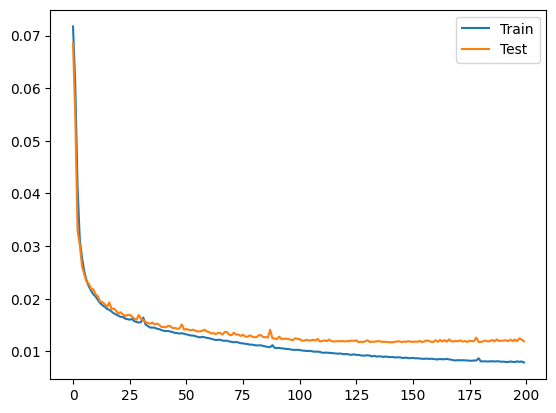

In [27]:
plt.plot(train_losses, label = "Train")
plt.plot(test_losses, label = "Test")
plt.legend()
plt.show()

In [28]:
class MLPDiscriminator(nn.Module):

    def __init__(self, input_dim, latent_dim):
        super().__init__()
        
        self.lin1 = nn.Linear(input_dim, latent_dim)
        self.lin2 = nn.Linear(latent_dim, 271)

    def forward(self, x):

        x = self.lin1(x)
        x = F.relu(x)
        x = self.lin2(x)
        
        return x

In [29]:
discriminator = MLPDiscriminator(512, 271)
model_neuro_distilled =Autoencoder()
import itertools
optimizer = optim.Adam(itertools.chain(model_neuro_distilled.parameters(), discriminator.parameters()), lr=lr)

In [30]:
device = "cuda" if torch.cuda.is_available else "cpu"
print("Running on ", device)

model_neuro_distilled.to(device)
discriminator.to(device)
neuro_test_losses = []
neuro_train_losses = []
reconstruction_train_losses = []

for epoch in range(epochs):
    total_loss_neuro = 0
    total_loss_reconstruction = 0

    for eeg_batch, img_batch, dino_output in tqdm(train_dataloader):
        
        optimizer.zero_grad()
        img_batch = img_batch.to(device)
        eeg_batch = eeg_batch.to(device).to(torch.float32)
        
        x_latent = model_neuro_distilled.encode(img_batch)
        
        brain_preds = discriminator(x_latent)
        reconstruction = model_neuro_distilled.decode(x_latent)
        
        reconstruction_loss = criterion(reconstruction, img_batch)
        neuro_guiding_loss = criterion (brain_preds, eeg_batch)

        loss = reconstruction_loss + 0.1*neuro_guiding_loss

        loss.backward()
        optimizer.step()

        total_loss_neuro += neuro_guiding_loss.item()
        total_loss_reconstruction += reconstruction_loss.item()

    print(f"Epoch [{epoch+1}/{epochs}] Train Reconstruction Loss: {total_loss_reconstruction / len(train_dataloader):.4f} Train Neuro Loss: {total_loss_neuro / len(train_dataloader):.4f}")

    neuro_train_losses.append(total_loss_neuro / len(train_dataloader))
    reconstruction_train_losses.append(total_loss_reconstruction / len(train_dataloader))
    
    total_test_loss = 0
    model_neuro_distilled.eval()
    with torch.no_grad():
        for eeg_batch, img_batch, dino_output in tqdm(test_dataloader):
        
            optimizer.zero_grad()
            img_batch = img_batch.to(device)
            eeg_batch = eeg_batch.to(device)
        
            x_recon = model_neuro_distilled(img_batch)

            loss = criterion(x_recon, img_batch)

            total_test_loss += loss.item()

        neuro_test_losses.append(total_test_loss/ len(test_dataloader))

        print(f"Epoch [{epoch+1}/{epochs}] Test Loss: {total_test_loss / len(test_dataloader):.4f}")

Running on  cuda


100%|██████████| 63/63 [00:12<00:00,  5.06it/s]


Epoch [1/200] Train Reconstruction Loss: 0.0663 Train Neuro Loss: 1.1620


100%|██████████| 16/16 [00:03<00:00,  4.70it/s]


Epoch [1/200] Test Loss: 0.0566


...

Epoch [199/200] Test Loss: 0.0150


100%|██████████| 63/63 [00:12<00:00,  5.07it/s]


Epoch [200/200] Train Reconstruction Loss: 0.0088 Train Neuro Loss: 0.1402


100%|██████████| 16/16 [00:03<00:00,  4.63it/s]

Epoch [200/200] Test Loss: 0.0151


In [ ]:
plt.plot(neuro_train_losses)
plt.show()

plt.plot(reconstruction_train_losses)
plt.show()

plt.figure(figsize = (16,8))
plt.title("Val reconstruction loss convergence comparison between MEG brain distillation and no brain distillation")
plt.plot(neuro_test_losses, label = "With brain distillation", c="r")
plt.plot(test_losses, label = "Whithout brain distillation", c= "blue")
plt.xlabel("Number of epochs")
plt.ylabel("Reconstruction MSE")
plt.legend()
plt.show()